In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from scipy.stats import wasserstein_distance
import matplotlib.patches as mpatches
import os
import sys

In [2]:
time_df = pd.read_csv('time_df.csv')
time_df = time_df.sort_values(by='Scenarios')

det_eq_times = time_df['Deterministic equivalent']
sur_0_times = time_df['Surrogate_0']
sur_1_times = time_df['Surrogate_1']
sur_2_times = time_df['Surrogate_2']


In [3]:
time_df

,Unnamed: 0,Scenarios,Deterministic equivalent,Surrogate_0,Surrogate_1,Surrogate_2,Surrogate_3,Surrogate_4
0,0,5.0,173.74,0.35,7.64,102.49,10800.0,10800.0
1,1,10.0,484.32,0.40,1.18,99.94,10800.0,10800.0
2,2,15.0,713.17,1.99,10.48,182.86,10800.0,10800.0
3,3,20.0,940.72,1.17,4.88,153.46,10800.0,10800.0
5,5,20.0,940.72,1.17,4.88,153.46,10800.0,10800.0
6,6,20.0,940.72,1.17,4.88,153.46,10800.0,10800.0
4,4,50.0,3010.15,1.78,6.60,163.77,10800.0,10800.0
7,7,50.0,3010.15,1.78,6.60,163.77,10800.0,10800.0
8,8,50.0,3010.15,1.78,6.60,163.77,10800.0,10800.0
9,9,50.0,3010.15,1.78,6.60,163.77,10800.0,10800.0


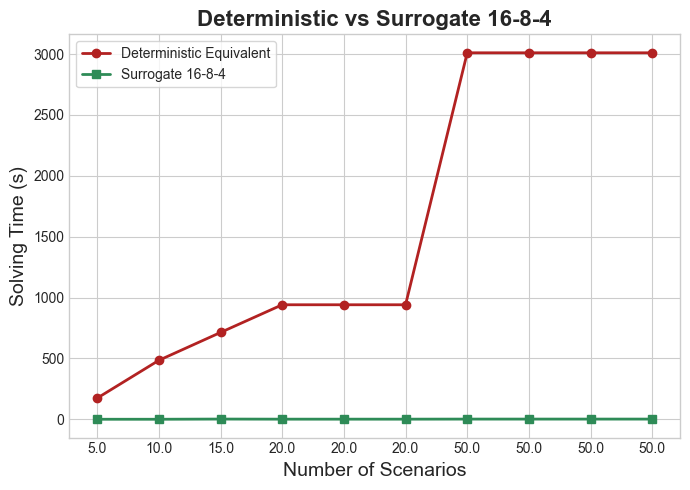

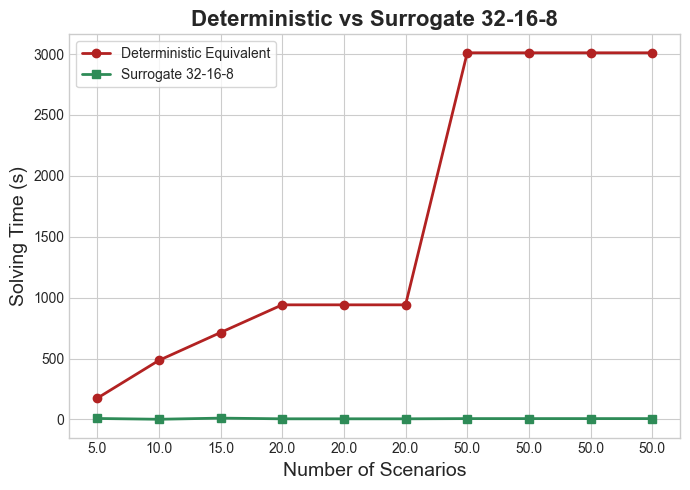

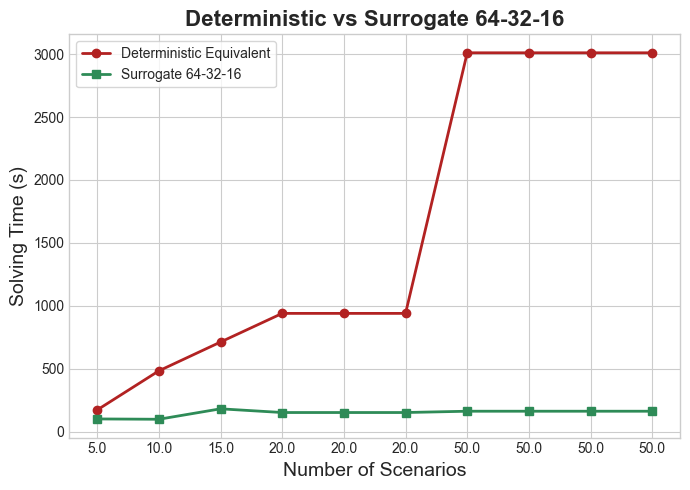

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")

def plot_comparison(x, det, sur, sur_label, ylim=None):
    plt.figure(figsize=(7,5))
    
    
    x_positions = range(len(x))
    
    plt.plot(x_positions, det, label="Deterministic Equivalent", color="firebrick", marker="o", linewidth=2)
    plt.plot(x_positions, sur, label=sur_label, color="seagreen", marker="s", linewidth=2)
    
    
    plt.xticks(x_positions, x)  
    
    plt.xlabel("Number of Scenarios", fontsize=14)
    plt.ylabel("Solving Time (s)", fontsize=14)
    plt.title(f"Deterministic vs {sur_label}", fontsize=16, weight="bold")
    plt.legend(frameon=True)
    
    if ylim is not None:
        plt.ylim(ylim)
    
    plt.tight_layout()
    plt.show()


plot_comparison(time_df["Scenarios"], det_eq_times, sur_0_times, "Surrogate 16-8-4")

plot_comparison(time_df["Scenarios"], det_eq_times, sur_1_times, "Surrogate 32-16-8")

plot_comparison(time_df["Scenarios"], det_eq_times, sur_2_times, "Surrogate 64-32-16")

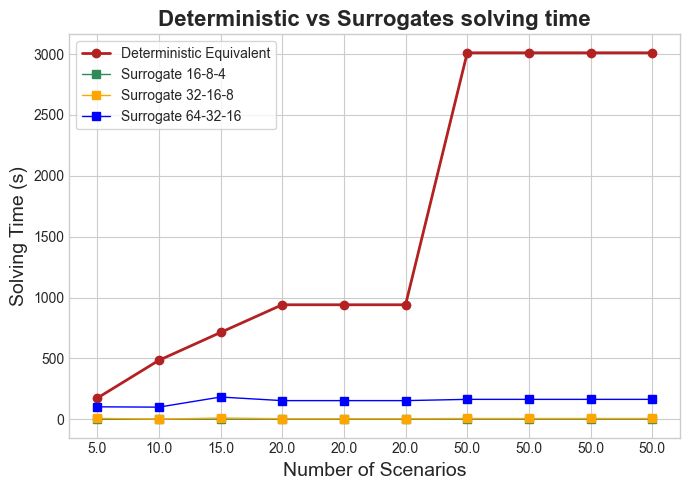

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

def plot_comparison_single_plot(x, det, sur0, sur1, sur2, ylim=None):
    plt.figure(figsize=(7,5))
    
    
    x_positions = range(len(x))
    
    plt.plot(x_positions, det, label="Deterministic Equivalent", color="firebrick", marker="o", linewidth=2)
    plt.plot(x_positions, sur0, label="Surrogate 16-8-4", color="seagreen", marker="s", linewidth=1)
    plt.plot(x_positions, sur1, label="Surrogate 32-16-8", color="orange", marker="s", linewidth=1)
    plt.plot(x_positions, sur2, label="Surrogate 64-32-16", color="blue", marker="s", linewidth=1)
    
    
    plt.xticks(x_positions, x)  
    
    plt.xlabel("Number of Scenarios", fontsize=14)
    plt.ylabel("Solving Time (s)", fontsize=14)
    plt.title(f"Deterministic vs Surrogates solving time", fontsize=16, weight="bold")
    plt.legend(frameon=True)
    
    if ylim is not None:
        plt.ylim(ylim)
    
    plt.tight_layout()
    plt.show()


plot_comparison_single_plot(time_df["Scenarios"], det_eq_times, sur_0_times, sur_1_times, sur_2_times)


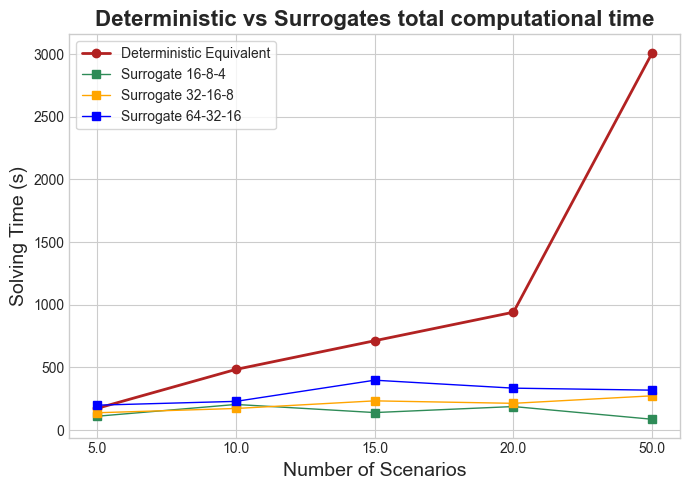

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")

def plot_comparison_single_plot(x, det, sur0, sur1, sur2, ylim=None):
    plt.figure(figsize=(7,5))
    
    
    x_positions = range(len(x))
    
    plt.plot(x_positions, det, label="Deterministic Equivalent", color="firebrick", marker="o", linewidth=2)
    plt.plot(x_positions, sur0, label="Surrogate 16-8-4", color="seagreen", marker="s", linewidth=1)
    plt.plot(x_positions, sur1, label="Surrogate 32-16-8", color="orange", marker="s", linewidth=1)
    plt.plot(x_positions, sur2, label="Surrogate 64-32-16", color="blue", marker="s", linewidth=1)
    
    
    plt.xticks(x_positions, x)  
    
    plt.xlabel("Number of Scenarios", fontsize=14)
    plt.ylabel("Solving Time (s)", fontsize=14)
    plt.title(f"Deterministic vs Surrogates total computational time", fontsize=16, weight="bold")
    plt.legend(frameon=True)
    
    if ylim is not None:
        plt.ylim(ylim)
    
    plt.tight_layout()
    plt.show()

time_df_trainAndSolve = pd.read_csv('time_df_trainAndSolve.csv')
det_eq_times = time_df_trainAndSolve['Deterministic equivalent']
sur_0_times = time_df_trainAndSolve['Surrogate_0']
sur_1_times = time_df_trainAndSolve['Surrogate_1']
sur_2_times = time_df_trainAndSolve['Surrogate_2']
plot_comparison_single_plot(time_df_trainAndSolve["Scenarios"], det_eq_times, sur_0_times, sur_1_times, sur_2_times)

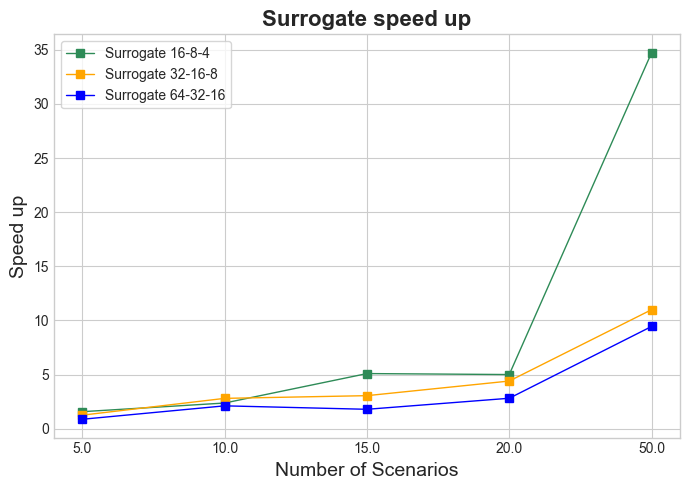

In [7]:
gap_sur0 = [1.57,2.37,5.09,5,34.72]
gap_sur1 = [1.25,2.8,3.05,4.4,10.99]
gap_sur2 = [0.87,2.11,1.79,2.81,9.44]

def plot_comparison_speedUp(x, sur0, sur1, sur2, ylim=None):
    plt.figure(figsize=(7,5))
    
    
    x_positions = range(len(x))
    
    plt.plot(x_positions, sur0, label="Surrogate 16-8-4", color="seagreen", marker="s", linewidth=1)
    plt.plot(x_positions, sur1, label="Surrogate 32-16-8", color="orange", marker="s", linewidth=1)
    plt.plot(x_positions, sur2, label="Surrogate 64-32-16", color="blue", marker="s", linewidth=1)
    
    
    plt.xticks(x_positions, x)  
    
    plt.xlabel("Number of Scenarios", fontsize=14)
    plt.ylabel("Speed up", fontsize=14)
    plt.title(f"Surrogate speed up", fontsize=16, weight="bold")
    plt.legend(frameon=True)
    
    if ylim is not None:
        plt.ylim(ylim)
    
    plt.tight_layout()
    plt.show()


plot_comparison_speedUp(time_df_trainAndSolve["Scenarios"], gap_sur0, gap_sur1, gap_sur2)

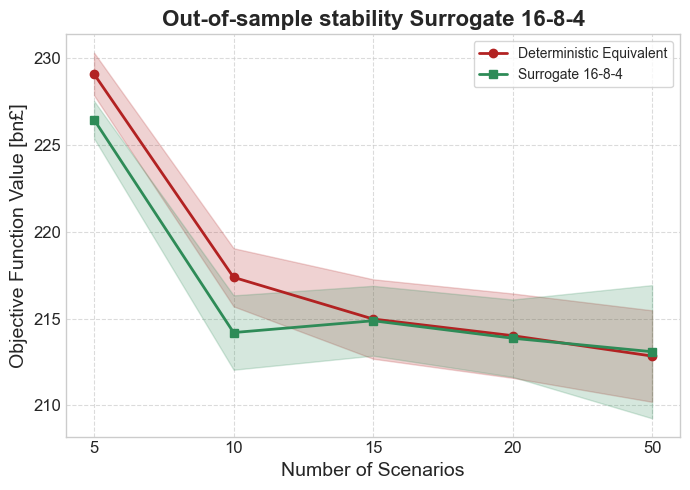

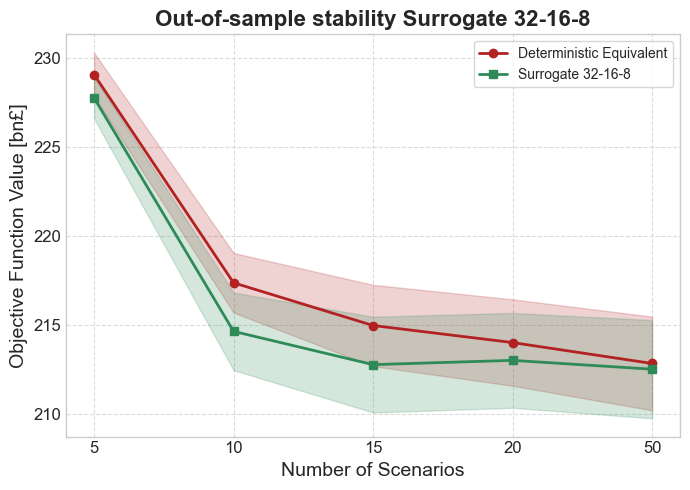

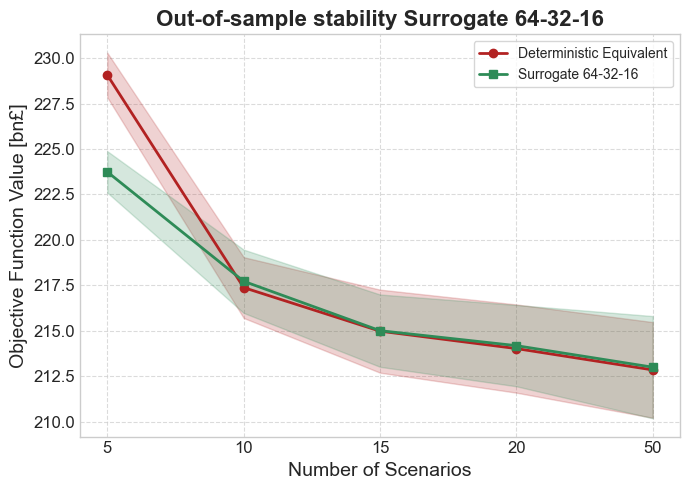

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


path_0 = "../Results Independent Scenarios/Results 5 scenarios/oos_solutions_5.csv"
path_1 = "../Results Independent Scenarios/Results 10 scenarios/oos_solutions_10.csv"
path_3 = "../Results Independent Scenarios/Results 20 scenarios/oos_solutions_20.csv"
path_2 = "../Results Independent Scenarios/Results 15 scenarios/oos_solutions_15.csv"
path_4 = "../Results Independent Scenarios/Results 50 scenarios/oos_solutions_50_1.csv"

oos_df_0 = pd.read_csv(path_0)
oos_df_1 = pd.read_csv(path_1)
oos_df_2 = pd.read_csv(path_2)
oos_df_3 = pd.read_csv(path_3)
oos_df_4 = pd.read_csv(path_4)


scenarios = [5, 10, 15, 20, 50]

deterministic_values = [
    oos_df_0["deterministic"],
    oos_df_1["deterministic"],
    oos_df_2["deterministic"],
    oos_df_3['deterministic'],
    oos_df_4['deterministic']
]

surrogate_labels = {
    0: "Surrogate 16-8-4",
    1: "Surrogate 32-16-8",
    2: "Surrogate 64-32-16"
}

n_surrogates = 3


def mean_ci(series, confidence=0.95):
    data = np.array(series)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    margin = 1.96 * std / np.sqrt(n) if n > 1 else 0
    return mean, margin


for n in range(n_surrogates):
    det_means, det_cis = [], []
    sur_means, sur_cis = [], []
    x_vals = []

    
    for scen, det_vals, oos_df in zip(scenarios, deterministic_values, [oos_df_0, oos_df_1, oos_df_2, oos_df_3, oos_df_4]):
        if f"surrogate_{n}" in oos_df.columns:  
           
            mean_det, ci_det = mean_ci(det_vals)
            mean_det /= 1000
            ci_det /= 1000
            det_means.append(mean_det)
            det_cis.append(ci_det)

            
            mean_sur, ci_sur = mean_ci(oos_df[f"surrogate_{n}"])
            mean_sur /= 1000
            ci_sur /= 1000
            sur_means.append(mean_sur)
            sur_cis.append(ci_sur)

            x_vals.append(scen)

    
    x_labels = [5, 10, 15, 20, 50]
    x_positions = np.arange(len(x_labels))  

    plt.figure(figsize=(7, 5))
    sur_label = surrogate_labels[n]

    plt.plot(x_positions, det_means, "-o", color="firebrick", linewidth=2, label="Deterministic Equivalent")
    plt.fill_between(x_positions,
                    np.array(det_means) - np.array(det_cis),
                    np.array(det_means) + np.array(det_cis),
                    color="firebrick", alpha=0.2)

    plt.plot(x_positions, sur_means, "-s", color="seagreen", linewidth=2, label=sur_label)
    plt.fill_between(x_positions,
                    np.array(sur_means) - np.array(sur_cis),
                    np.array(sur_means) + np.array(sur_cis),
                    color="seagreen", alpha=0.2)

    plt.xticks(x_positions, x_labels)  
    plt.xlabel("Number of Scenarios", fontsize=14)
    plt.ylabel("Objective Function Value [bn£]", fontsize=14)
    plt.title(f"Out-of-sample stability {sur_label}", fontsize=16, weight="bold")
    plt.legend(frameon=True)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    
    

In [9]:
path_0 = '../Results Independent Scenarios/Results 5 scenarios/in_sample_results_independent_5scen.csv'
path_1 = '../Results Independent Scenarios/Results 10 scenarios/in_sample_results_independent_10scen.csv'
path_2 = '../Results Independent Scenarios/Results 15 scenarios/in_sample_results_independent_15scen.csv'
path_3 = '../Results Independent Scenarios/Results 20 scenarios/in_sample_results_independent_20scen.csv'
path_4 = '../Results Independent Scenarios/Results 50 scenarios/in_sample_results_independent_50scen.csv'

iss_df_0 = pd.read_csv(path_0)
iss_df_1 = pd.read_csv(path_1)
iss_df_2 = pd.read_csv(path_2)
iss_df_3 = pd.read_csv(path_3)
iss_df_4 = pd.read_csv(path_4)

scenarios = [5, 10, 15, 20, 50]

surrogate_labels = {
    0: "Surrogate 16-8-4",
    1: "Surrogate 32-16-8",
    2: "Surrogate 64-32-16"
}

In [10]:
data_long = []


data_long.append(pd.DataFrame({
    "Method": "Deterministic equivalent",
    "Value": iss_df_0["deterministic_objs"].tolist() 
             + iss_df_1["deterministic_objs"].tolist()
             + iss_df_2["deterministic_objs"].tolist()
             + iss_df_3["deterministic_objs"].tolist()
             + iss_df_4["deterministic_objs"].tolist()
}))

for n, label in surrogate_labels.items():
    vals = []
    if f"surrogate_{n}_objs" in iss_df_0.columns:
        vals += iss_df_0[f"surrogate_{n}_objs"].tolist()
    if f"surrogate_{n}_objs" in iss_df_1.columns:
        vals += iss_df_1[f"surrogate_{n}_objs"].tolist()
    if f"surrogate_{n}_objs" in iss_df_2.columns:
        vals += iss_df_2[f"surrogate_{n}_objs"].tolist()
    if f"surrogate_{n}_objs" in iss_df_3.columns:
        vals += iss_df_3[f"surrogate_{n}_objs"].tolist()
    if f"surrogate_{n}_objs" in iss_df_4.columns:
        vals += iss_df_4[f"surrogate_{n}_objs"].tolist()
    
    data_long.append(pd.DataFrame({
        "Method": label,
        "Value": vals
    }))

plot_df = pd.concat(data_long, ignore_index=True)


In [11]:
sns.set_style("whitegrid")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Common boxplot visual props
box_kwargs = dict(
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 5}
)

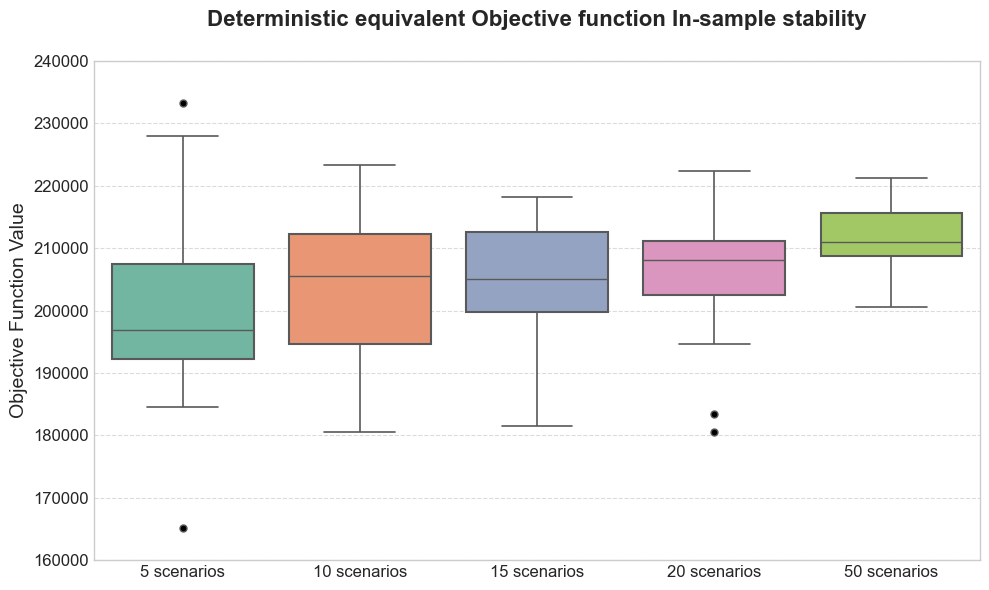

In [12]:
det_df = pd.DataFrame({
    "5 scenarios": iss_df_0["deterministic_objs"].reset_index(drop=True),
    "10 scenarios": iss_df_1["deterministic_objs"].reset_index(drop=True),
    "15 scenarios": iss_df_2["deterministic_objs"].reset_index(drop=True),
    "20 scenarios": iss_df_3["deterministic_objs"].reset_index(drop=True),
    "50 scenarios": iss_df_4["deterministic_objs"].reset_index(drop=True),
})

fig, ax = plt.subplots(figsize=(10, 6))
palette_det = sns.color_palette("Set2", n_colors=5)
sns.boxplot(data=det_df, palette=palette_det, ax=ax, **box_kwargs)

ax.set_title("Deterministic equivalent Objective function In-sample stability",
             weight="bold", fontsize=16, pad=25)
ax.set_ylabel("Objective Function Value", fontsize=14)

ax.set_ylim(160000, 240000)
yticks = range(160000, 240001, 10000)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y}" for y in yticks])

ax.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

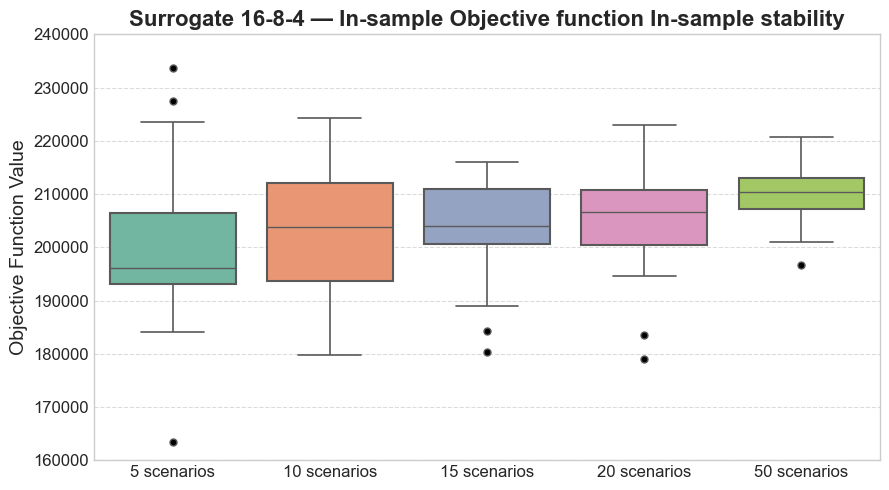

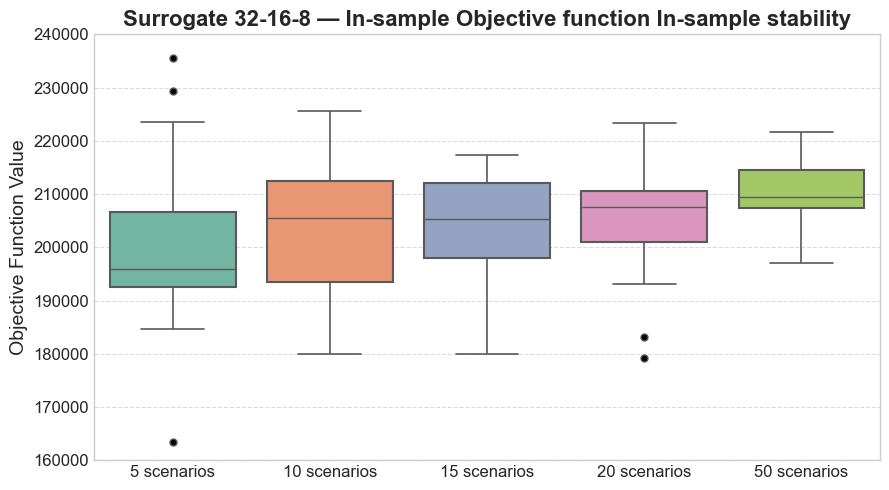

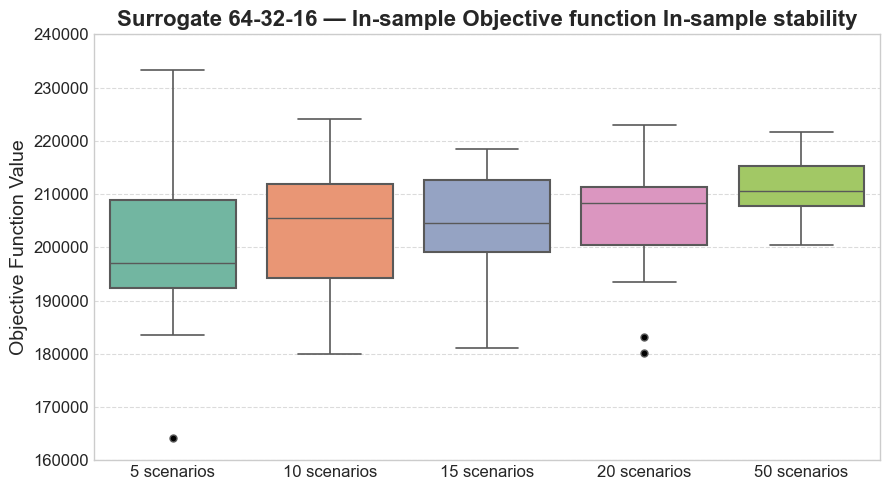

In [13]:
all_surrogate = pd.DataFrame()
for n, label in surrogate_labels.items():
    # gather data for available scenarios
    sur_cols = []
    sur_names = []
    if f"Surrogate_{n}_objs" in iss_df_0.columns:
        sur_cols.append(iss_df_0[f"Surrogate_{n}_objs"].reset_index(drop=True))
        sur_names.append("5 scenarios")
        all_surrogate[f'Surrogate_{n}_5_scen'] = iss_df_0[f"Surrogate_{n}_objs"].reset_index(drop=True)
    if f"Surrogate_{n}_objs" in iss_df_1.columns:
        sur_cols.append(iss_df_1[f"Surrogate_{n}_objs"].reset_index(drop=True))
        sur_names.append("10 scenarios")
        all_surrogate[f'Surrogate_{n}_10_scen'] = iss_df_1[f"Surrogate_{n}_objs"].reset_index(drop=True)
    if f"Surrogate_{n}_objs" in iss_df_2.columns:
        sur_cols.append(iss_df_2[f"Surrogate_{n}_objs"].reset_index(drop=True))
        sur_names.append("15 scenarios")
        all_surrogate[f'Surrogate_{n}_15_scen'] = iss_df_2[f"Surrogate_{n}_objs"].reset_index(drop=True)
    if f"Surrogate_{n}_objs" in iss_df_3.columns:
        sur_cols.append(iss_df_3[f"Surrogate_{n}_objs"].reset_index(drop=True))
        sur_names.append("20 scenarios")
        all_surrogate[f'Surrogate_{n}_20_scen'] = iss_df_3[f"Surrogate_{n}_objs"].reset_index(drop=True)
    if f"Surrogate_{n}_objs" in iss_df_4.columns:
        sur_cols.append(iss_df_4[f"Surrogate_{n}_objs"].reset_index(drop=True))
        sur_names.append("50 scenarios")
        all_surrogate[f'Surrogate_{n}_50_scen'] = iss_df_4[f"Surrogate_{n}_objs"].reset_index(drop=True)

    if len(sur_cols) == 0:
        # nothing to plot for this surrogate
        continue

   
    sur_df = pd.concat([s.rename(name) for s, name in zip(sur_cols, sur_names)], axis=1)

    plt.figure(figsize=(9, 5))
    palette_sur = sns.color_palette("Set2", n_colors=len(sur_names))
    ax = sns.boxplot(data=sur_df, palette=palette_sur, **box_kwargs)

    ax.set_title(f"{label} — In-sample Objective function In-sample stability", weight="bold", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("Objective Function Value", fontsize=14)
    ax.set_ylim(160000, 240000)
    yticks = range(160000, 240001, 10000)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y}" for y in yticks])

    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
   

    plt.tight_layout()
    plt.show()

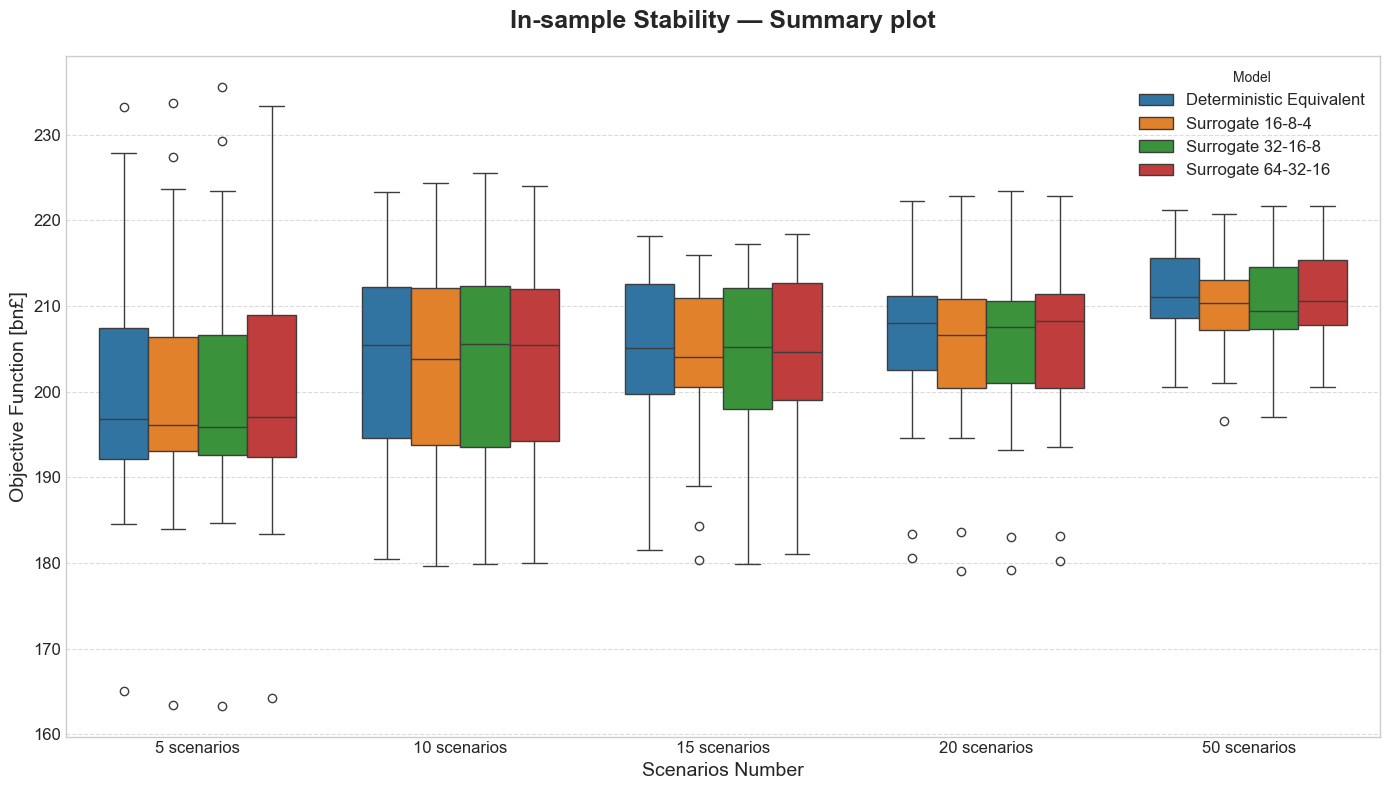

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def to_long(df, model_name):
    """Trasforma un DF wide in long con tag del modello."""
    long = df.melt(var_name="Scenarios",
                   value_name="Objective")
    long["Model"] = model_name
    return long

s0 = all_surrogate[['Surrogate_0_5_scen','Surrogate_0_10_scen','Surrogate_0_15_scen',
                    'Surrogate_0_20_scen','Surrogate_0_50_scen']].copy()
s0.columns = ["5 scenarios","10 scenarios","15 scenarios","20 scenarios","50 scenarios"]

s1 = all_surrogate[['Surrogate_1_5_scen','Surrogate_1_10_scen','Surrogate_1_15_scen',
                    'Surrogate_1_20_scen','Surrogate_1_50_scen']].copy()
s1.columns = ["5 scenarios","10 scenarios","15 scenarios","20 scenarios","50 scenarios"]

s2 = all_surrogate[['Surrogate_2_5_scen','Surrogate_2_10_scen','Surrogate_2_15_scen',
                    'Surrogate_2_20_scen','Surrogate_2_50_scen']].copy()
s2.columns = ["5 scenarios","10 scenarios","15 scenarios","20 scenarios","50 scenarios"]


long_det   = to_long(det_df,   "Deterministic Equivalent")
long_s0   = to_long(s0, "Surrogate 16-8-4")
long_s1    = to_long(s1,  "Surrogate 32-16-8")
long_s2    = to_long(s2, "Surrogate 64-32-16")


df_all = pd.concat([long_det, long_s0, long_s1, long_s2], ignore_index=True)
df_all["Objective"] = df_all["Objective"]/1000

scenario_order = ["5 scenarios","10 scenarios","15 scenarios","20 scenarios","50 scenarios"]



plt.figure(figsize=(14,8))
sns.boxplot(
    data=df_all,
    x="Scenarios",
    y="Objective",
    hue="Model",
    order=scenario_order,
    width=0.75
)

plt.title("In-sample Stability — Summary plot", fontsize=18, weight="bold", pad=20)
plt.xlabel("Scenarios Number", fontsize=14)
plt.ylabel("Objective Function [bn£]", fontsize=14)
plt.grid(True, axis='y', linestyle="--", alpha=0.7)
plt.legend(title="Model", fontsize=12)
plt.tight_layout()
plt.show()